In [238]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime,timedelta

In [239]:
claims = pd.read_csv(r"claims.csv")
cust_demo = pd.read_csv(r"cust_demographics.csv")

In [240]:
claims.shape

(1100, 10)

In [241]:
cust_demo.shape

(1085, 6)

In [242]:
claims.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   claim_id             1100 non-null   int64  
 1   customer_id          1100 non-null   int64  
 2   incident_cause       1100 non-null   object 
 3   claim_date           1100 non-null   object 
 4   claim_area           1100 non-null   object 
 5   police_report        1100 non-null   object 
 6   claim_type           1100 non-null   object 
 7   claim_amount         1035 non-null   object 
 8   total_policy_claims  1090 non-null   float64
 9   fraudulent           1100 non-null   object 
dtypes: float64(1), int64(2), object(7)
memory usage: 86.1+ KB


In [243]:
claims.head()

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No
1,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No
2,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes
3,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,$1680,1.0,No
4,22890252,19269962,Crime,01/13/2018,Auto,No,Material only,$2680,1.0,No


In [244]:
cust_demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CUST_ID      1085 non-null   int64 
 1   gender       1085 non-null   object
 2   DateOfBirth  1085 non-null   object
 3   State        1085 non-null   object
 4   Contact      1085 non-null   object
 5   Segment      1085 non-null   object
dtypes: int64(1), object(5)
memory usage: 51.0+ KB


In [245]:
cust_demo.head()

,CUST_ID,gender,DateOfBirth,State,Contact,Segment
0,21868593,Female,12-Jan-79,VT,789-916-8172,Platinum
1,75740424,Female,13-Jan-70,ME,265-543-1264,Silver
2,30308357,Female,11-Mar-84,TN,798-631-4758,Silver
3,47830476,Female,01-May-86,MA,413-187-7945,Silver
4,19269962,Male,13-May-77,NV,956-871-8691,Gold


In [246]:
df_merge = claims.merge(right=cust_demo,left_on="customer_id",right_on="CUST_ID",how="inner").drop(columns="CUST_ID")

In [247]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   claim_id             1085 non-null   int64  
 1   customer_id          1085 non-null   int64  
 2   incident_cause       1085 non-null   object 
 3   claim_date           1085 non-null   object 
 4   claim_area           1085 non-null   object 
 5   police_report        1085 non-null   object 
 6   claim_type           1085 non-null   object 
 7   claim_amount         1020 non-null   object 
 8   total_policy_claims  1075 non-null   float64
 9   fraudulent           1085 non-null   object 
 10  gender               1085 non-null   object 
 11  DateOfBirth          1085 non-null   object 
 12  State                1085 non-null   object 
 13  Contact              1085 non-null   object 
 14  Segment              1085 non-null   object 
dtypes: float64(1), int64(2), object(12)
me

In [248]:
df_merge.head()

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment
0,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No,Female,12-Jan-79,VT,789-916-8172,Platinum
1,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No,Female,13-Jan-70,ME,265-543-1264,Silver
2,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes,Female,11-Mar-84,TN,798-631-4758,Silver
3,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,$1680,1.0,No,Female,01-May-86,MA,413-187-7945,Silver
4,22890252,19269962,Crime,01/13/2018,Auto,No,Material only,$2680,1.0,No,Male,13-May-77,NV,956-871-8691,Gold


In [249]:
# Data cleaning

In [250]:
df_merge["claim_date"] = pd.to_datetime(df_merge.claim_date,format="%m/%d/%Y")
df_merge["DateOfBirth"] = pd.to_datetime(df_merge.DateOfBirth,format="%d-%b-%y")

In [251]:
df_merge["Contact"] = df_merge.Contact.str.replace("-","")
df_merge["claim_amount"] = df_merge.claim_amount.str.replace("$","").astype("float")

In [252]:
df_merge

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment
0,54004764,21868593,Driver error,2017-11-27,Auto,No,Material only,2980.0,1.0,No,Female,1979-01-12,VT,7899168172,Platinum
1,33985796,75740424,Crime,2018-10-03,Home,Unknown,Material only,2980.0,3.0,No,Female,1970-01-13,ME,2655431264,Silver
2,53522022,30308357,Other driver error,2018-02-02,Auto,No,Material only,3369.5,1.0,Yes,Female,1984-03-11,TN,7986314758,Silver
3,13015401,47830476,Natural causes,2018-06-17,Auto,No,Material only,1680.0,1.0,No,Female,1986-05-01,MA,4131877945,Silver
4,22890252,19269962,Crime,2018-01-13,Auto,No,Material only,2680.0,1.0,No,Male,1977-05-13,NV,9568718691,Gold
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1080,62020796,79539873,Other driver error,2018-09-06,Auto,Yes,Material only,1770.0,1.0,No,Female,1981-03-15,ND,4594254319,Platinum
1081,63269067,42364152,Other causes,2017-05-09,Home,No,Material only,2800.0,1.0,No,Female,1996-07-07,ID,5294621635,Silver
1082,22690595,19888166,Other driver error,2017-05-15,Auto,Yes,Injury only,33080.0,2.0,No,Male,1990-04-11,WI,7126519613,Gold
1083,12376894,11256802,Other driver error,2017-04-18,Auto,No,Material only,2840.0,4.0,No,Female,2064-10-22,LA,4693455617,Silver


In [253]:
# Cotegorical columns check
for i in df_merge[['incident_cause','claim_area','police_report', 'claim_type','total_policy_claims',
                    'fraudulent', 'gender', 'State', 'Contact', 'Segment']]:
    print(df_merge[i].value_counts())
    print("\n")

incident_cause
Other causes          285
Driver error          261
Other driver error    245
Natural causes        186
Crime                 108
Name: count, dtype: int64


claim_area
Auto    970
Home    115
Name: count, dtype: int64


police_report
No         621
Unknown    296
Yes        168
Name: count, dtype: int64


claim_type
Material only          653
Material and injury    237
Injury only            195
Name: count, dtype: int64


total_policy_claims
1.0    785
2.0    105
3.0     86
4.0     59
5.0     27
6.0     10
7.0      2
8.0      1
Name: count, dtype: int64


fraudulent
No     838
Yes    247
Name: count, dtype: int64


gender
Male      556
Female    529
Name: count, dtype: int64


State
NY    31
AR    29
DE    29
AL    28
ME    28
ND    27
ID    27
TN    27
RI    26
IA    26
NV    26
MA    26
SD    25
CO    25
CT    25
FL    24
NC    24
WI    23
IL    23
TX    22
IN    22
OH    22
MO    22
VT    22
NE    21
PA    21
MD    21
OK    21
AK    20
WV    20
MT    20
LA    20
NM 

In [254]:
# Continous Columns Check
df_merge.describe().T

,count,mean,min,25%,50%,75%,max,std
claim_id,1085.0,48915528.400922,26832.0,24046062.0,48559754.0,74043997.0,99775483.0,29128181.617819
customer_id,1085.0,50767904.341935,154557.0,26450621.0,49759488.0,76093960.0,99961993.0,28496245.372373
claim_date,1085,2017-11-26 01:03:42.304147456,2017-01-01 00:00:00,2017-06-04 00:00:00,2017-11-27 00:00:00,2018-05-14 00:00:00,2018-10-30 00:00:00,NaN
claim_amount,1020.0,12467.681373,1000.0,1870.0,2740.0,24260.0,48150.5,13783.249662
total_policy_claims,1075.0,1.586977,1.0,1.0,1.0,2.0,8.0,1.146859
DateOfBirth,1085,2002-10-05 12:20:34.285714176,1969-01-01 00:00:00,1979-05-09 00:00:00,1989-06-11 00:00:00,1999-02-20 00:00:00,2068-12-19 00:00:00,NaN


### Of all the injury claims, some of them have gone unreported with the police. Create an alert flag (1,0) for all such claims.

In [256]:
df_merge["Alert_Flag"] = np.where((df_merge.claim_type == "Injury only") & (df_merge.police_report == "No"),1,0)

### One customer can claim for insurance more than once and in each claim, multiple categories of claims can be involved. However, customer ID should remain unique.
Retain the most recent observation and delete any duplicated records in
the data based on the customer ID column.

In [258]:
df1 = df_merge.customer_id.value_counts().reset_index()
dup_cust = df1[df1["count"] > 1]
df2 = df_merge[df_merge.customer_id.isin(dup_cust.customer_id)]
d_rows = pd.DataFrame(df2.groupby("customer_id").claim_date.min().reset_index())
drop_row = df_merge.loc[df_merge.customer_id.isin(d_rows.customer_id) & df_merge.claim_date.isin(d_rows.claim_date)]
df_merge.drop(drop_row.index,inplace=True)

### Check for missing values and impute the missing values with an appropriate value. (mean for continuous and mode for categorical)

In [260]:
df_merge["claim_amount"] = df_merge.claim_amount.fillna(df_merge["claim_amount"].mean())
df_merge["total_policy_claims"] = df_merge["total_policy_claims"].fillna(df_merge["total_policy_claims"].mode()[0])

### Calculate the age of customers in years. Based on the age, categorize the customers according to the below criteria
Children < 18
Youth 18-30
Adult 30-60
Senior > 60

In [262]:
df_merge["DateOfBirth"] = df_merge.DateOfBirth.apply(lambda x: x.replace(year=x.year - 100) if x > pd.Timestamp("2050-01-01") else x)
df_merge["Age"] = (( df_merge.claim_date.max() - df_merge.DateOfBirth )/pd.Timedelta(days=365.25)).astype("int")

In [263]:
df_merge["Age_group"] = np.where(df_merge.Age < 18, "children",
         np.where((df_merge.Age >=18) & (df_merge.Age <= 30),"Youth",
         np.where((df_merge.Age >= 30) & (df_merge.Age <= 60),"Adult","Senior")))

### What is the average amount claimed by the customers from various segments?

In [265]:
df_merge.groupby("Segment").claim_amount.mean().reset_index()

,Segment,claim_amount
0,Gold,12846.400227
1,Platinum,12371.654843
2,Silver,12267.859374


### 9. What is the total claim amount based on incident cause for all the claims that have been done at least 20 days prior to 1st of October, 2018.

In [267]:
cutoff_date = pd.Timestamp("2018-10-01") - pd.Timedelta(days=20)
df_grouped = df_merge.loc[df_merge.claim_date <= cutoff_date]
df_grouped.groupby("incident_cause").claim_amount.sum().reset_index().T

,0,1,2,3,4
incident_cause,Crime,Driver error,Natural causes,Other causes,Other driver error
claim_amount,721938.632774,3315850.718657,1312987.038993,3723151.804541,3277536.445212


### How many adults from TX, DE and AK claimed insurance for driver related issues and causes? 

In [269]:
df_merge.loc[(df_merge.State.isin(['TX', 'DE', 'AK'])) & (df_merge.incident_cause.isin(['Driver error','Other driver error']))
               & ( df_merge.Age_group == "Adult")].customer_id.nunique()

24

###  Draw a pie chart between the aggregated value of claim amount based on gender and segment. Represent the claim amount as a percentage on the pie chart.


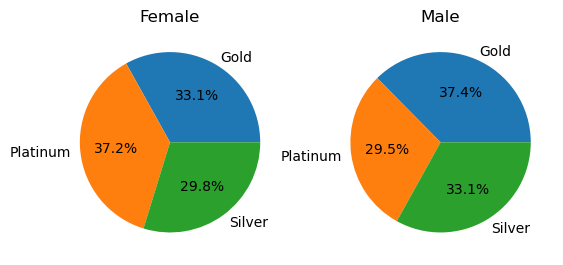

In [271]:
result1 = df_merge.groupby(['gender','Segment']).claim_amount.sum().reset_index()

fig, axs = plt.subplots(1,2)

for i,k in enumerate(result1.gender.unique()):
    axs[i].pie(x=result1[result1['gender'] == k].claim_amount,labels=result1[result1['gender'] == k].Segment,autopct = "%1.1f%%")
    axs[i].set_title(k)

###  Among males and females, which gender had claimed the most for any type of driver related issues? E.g. This metric can be compared using a bar chart


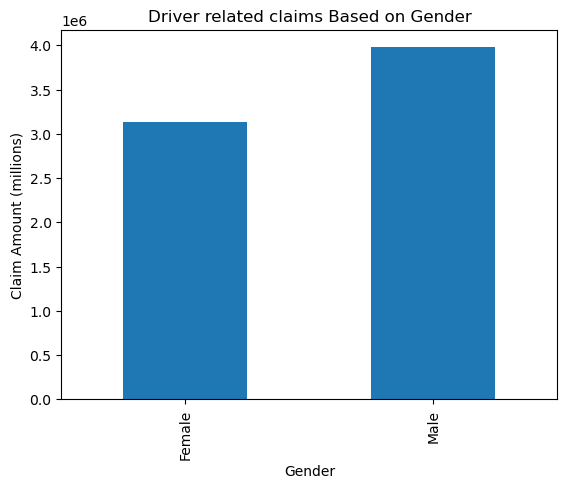

In [273]:
df3 = df_merge.loc[df_merge.incident_cause.isin(["Driver error", "Other driver error"])]
result2 = df3.groupby("gender").claim_amount.sum().reset_index()

result2.plot(x="gender",y="claim_amount",kind="bar",title="Driver related claims Based on Gender",legend=False)
plt.xlabel("Gender")
plt.ylabel("Claim Amount (millions)")
plt.show()

###  Which age group had the maximum fraudulent policy claims? Visualize it on a bar chart.

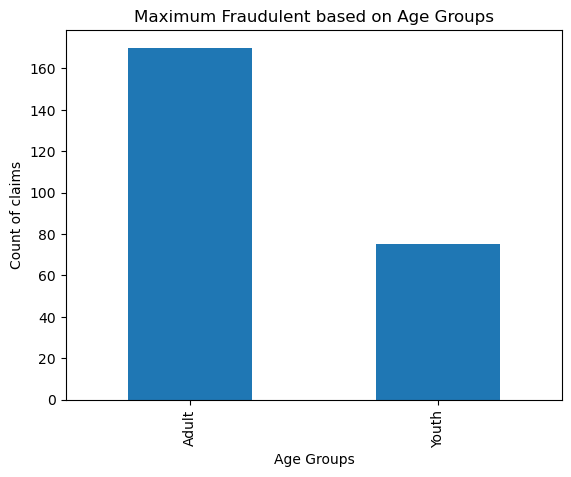

In [275]:
result3 = df_merge[df_merge.fraudulent == 'Yes'].groupby("Age_group").claim_id.count().reset_index()
result3.plot(x="Age_group",y="claim_id",kind="bar",title="Maximum Fraudulent based on Age Groups",legend= False)
plt.xlabel("Age Groups")
plt.ylabel("Count of claims")
plt.show()

### Visualize the monthly trend of the total amount that has been claimed by the customers. Ensure that on the “month” axis, the month is in a chronological order not alphabetical order.

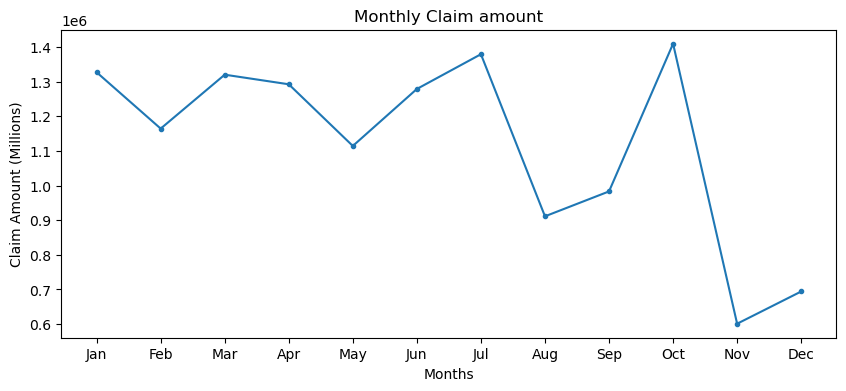

In [277]:
result4 = df_merge.groupby(df_merge.claim_date.dt.month).claim_amount.sum().reset_index().sort_values(by='claim_date')
month_dict = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
result4["Month_name"] = result4.claim_date.map(month_dict)

result4.plot(x="Month_name",y="claim_amount",marker="o",markersize=3,title="Monthly Claim amount",figsize=(10,4),legend=False)
plt.xlabel("Months")
plt.ylabel("Claim Amount (Millions)")
plt.xticks(ticks=[0,1,2,3,4,5,6,7,8,9,10,11],labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

### What is the average claim amount for gender and age categories and suitably represent the above using a facetted bar chart, one facet that represents fraudulent claims and the other for non-fraudulent claims

In [279]:
df4 = df_merge.groupby(['fraudulent','gender','Age_group']).claim_amount.mean().reset_index()

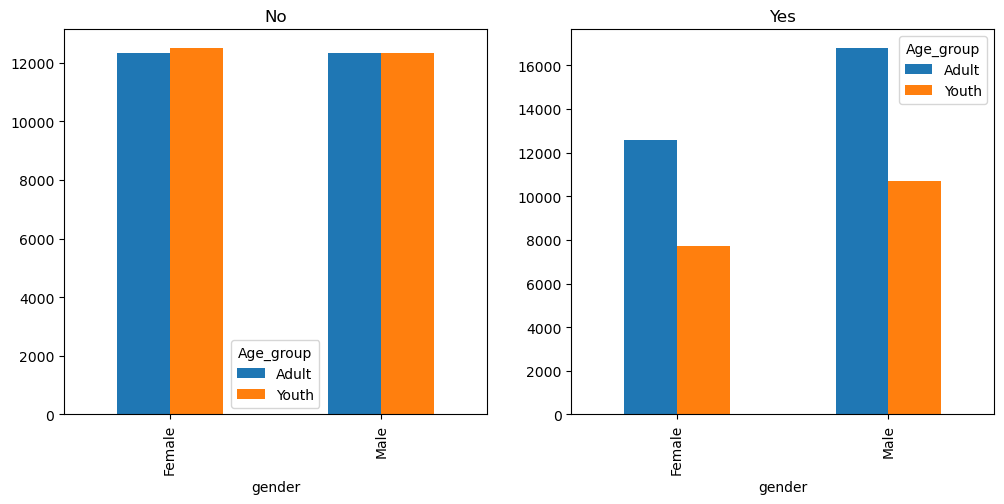

In [280]:
fig,axs = plt.subplots(1,2 , figsize=(12,5))

for i,x in enumerate(df4.fraudulent.unique()):
    df5 = df4[df4['fraudulent'] == x].pivot_table(columns='Age_group',index='gender',values='claim_amount')
    df5.plot(kind='bar',ax=axs[i],title=x)
plt.show()

## Hypothesis Testing

### Is there any similarity in the amount claimed by males and females?

In [283]:
# H0: No rltn
# HA: rltn exists

# Confidence interval = 95% , Significance = 5%

In [284]:
male = df_merge.loc[df_merge.gender == 'Male'].claim_amount
female = df_merge.loc[df_merge.gender == 'Female'].claim_amount

In [285]:
import scipy.stats as stats
stats.ttest_ind(male,female)

TtestResult(statistic=0.9625093446632118, pvalue=0.33601006135365463, df=1076.0)

In [286]:
# As the P-value is high we fail to reject the null
# So, there is no similarity between amount claimed by males and females

### Is there any relationship between age category and segment?

In [288]:
# H0 : No Relationship b/w age group and segment
# Ha : Relation exists

# confidence interval : 95%, significance : 5%

In [289]:
observed = pd.crosstab(index=df_merge.Segment,columns = df_merge.Age_group)

In [290]:
stats.chi2_contingency(observed)

Chi2ContingencyResult(statistic=0.949398850160443, pvalue=0.6220720076109839, dof=2, expected_freq=array([[254.33116883, 116.66883117],
       [247.47588126, 113.52411874],
       [237.19294991, 108.80705009]]))

In [291]:
## So p is very high than significance so we fail to reject the null, there is no rltn

###  The current year has shown a significant rise in claim amounts as compared to 2016-17 fiscal average which was $10,000

In [308]:
# H0 : avg claim amount = 10000
# Ha : avg claim amount > 10000

# Significance = 5%

In [350]:
s = df_merge.loc[df_merge.claim_date.dt.year == 2018,'claim_amount']

In [358]:
stats.ttest_1samp(s,10000,alternative='greater')

TtestResult(statistic=4.477343563243787, pvalue=4.717922110991665e-06, df=484)

In [360]:
# p is very low so we reject the null value and we can say this year amount is greater than 10000

### Is there any difference between age groups and insurance claims?

In [ ]:
# H0 : Adult = Youth
# Ha : Adult <> Youth

# Significance = 5%

In [373]:
Adult_claim = df_merge.loc[df_merge['Age_group'] == 'Adult', 'claim_amount']
youth_claim = df_merge.loc[df_merge['Age_group'] == 'Youth', 'claim_amount']

In [377]:
stats.ttest_ind(Adult_claim,youth_claim)

TtestResult(statistic=1.31638470258395, pvalue=0.1883252887511758, df=1076.0)

In [381]:
## As the p-value is higher than significance we can there is no considerable difference b/w age groups

### Is there any relationship between total number of policy claims and the claimed amount?


In [ ]:
# H0: No rltn
# Ha: relation exists

# significance : 5%

In [401]:
total_claims = df_merge.total_policy_claims
claim_amount = df_merge.claim_amount

In [405]:
stats.pearsonr(total_claims,claim_amount)

PearsonRResult(statistic=-0.022401566777628838, pvalue=0.4624932766044221)

In [ ]:
# as per the statistic we can say there is no relationship between policy claims and claimed amount and p value is also high so the null will stay.